## **Climate Variability, Forest Loss, and Ebola Outbreak Intensity in Liberia (2014-2016)**
### A Spatial Climate Analysis of Environmental Disease Risk

#### CLMT 5053: Computing and Research Methods for Climate Data Science | **Final Project**
#### Caitlin Traver (cjt2162) | May 12, 2026

### 1.0 Project Background

#### This project supports my Disaster Research Methods project on the 2014–2016 Ebola outbreak in Liberia, which examines how forest fragmentation and human behavior influenced disease transmission risk. That research finds that communities near forest–savannah transition zones and areas of environmental change may experience higher exposure to Ebola due to increased human–wildlife interaction. In this project, I extend that framework by investigating whether climate variability, specifically temperature and precipitation anomalies, acted as an additional environmental driver influencing the spatial distribution and intensity of Ebola outbreaks across Liberia.

#### By integrating climate data, land-use change data, and county-level Ebola case data, this project explores how climate and environmental change together may contribute to patterns of infectious disease risk.

### Research Question

#### How do climate variability (temperature and precipitation anomalies) and land-use change (forest loss and fragmentation) relate to the spatial variation of Ebola outbreak intensity across Liberia during the 2014–2016 epidemic?

### Hypothesis

#### Liberian counties experiencing both significant forest loss and stronger climate anomalies (higher temperature variability and abnormal precipitation) will exhibit greater Ebola outbreak intensity than counties experiencing only one or neither of these environmental stressors.

### Analysis

#### The analysis will integrate climate, land-use, and epidemiological datasets to examine how environmental factors relate to Ebola county-level outbreak intensity in Liberia. Using xarray, I will process gridded climate data to calculate temperature and precipitation anomalies relative to a pre-outbreak baseline period. Forest loss data will be used to quantify land-use change and identify high and low deforestation regions. These datasets will be spatially aligned with Ebola case data, allowing extraction of climate conditions and land-use characteristics at outbreak locations. Using NumPy and matplotlib, the analysis compares climate anomalies, forest-loss intensity, and Ebola case density across Liberian counties through exploratory spatial visualization, scatterplot comparisons, grouped environmental risk categories, and integrated mapping of outbreak intensity and environmental change.

### Datasets

#### 1.  Climate Data: **CRU TS Dataset**
    Monthly gridded climate data (temperature and precipitation) from the Climate Research Unit, used to calculate climate variability and anomalies during the Ebola outbreak period.
    https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.08/

#### 2.  Land Use Data: **Hansen Global Forest Change Dataset**
    High-resolution global forest cover and forest loss data used to quantify deforestation and identify areas of forest 
    fragmentation prior to and during the outbreak.
    https://earthenginepartners.appspot.com/science-2013-global-forest

#### 3.  Ebola Case Data: **Humanitarian Data Exchange (HDX)**
    County-level cumulative Ebola case totals for Liberia during the 2014–2016 outbreak were compiled from publicly available epidemiological datasets provided through the Humanitarian
    Data Exchange (HDX). The original outbreak records were cleaned, aggregated, and reformatted into a county-level CSV dataset for spatial analysis and visualization.
    https://data.humdata.org/dataset/ebola-cases-2014

### 2.0 Preparation
##### The following Python libraries were imported to support data downloading, file management, geospatial processing, and climate raster analysis throughout the project:

In [155]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import geopandas as gpd

import os   # manages file paths and creates local directories for downloaded datasets
import zipfile   # extracts compressed ZIP archives containing shapefiles and geospatial datasets
import urllib.request   # downloads climate and forest-loss datasets directly from online repositories within the notebook
import sys   # accesses the active Python environment and supports package installation within the notebook environment
import rioxarray   # loads and processes georeferenced raster datasets, including Hansen forest-loss GeoTIFF files, while preserving spatial coordinate reference information

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

# Liberia approximate bounding box:
LON_MIN, LON_MAX = -12.0, -7.0
LAT_MIN, LAT_MAX = 4.0, 9.0

# Define 'normal' reference climate for Liberia before the Ebola outbreak:
BASELINE_START = "2010-01-01"
BASELINE_END   = "2013-12-31"

# Define Ebola outbreak analysis period:
OUTBREAK_START = "2014-03-01"
OUTBREAK_END   = "2016-03-31"

### 3.0 Import Datasets

#### 3.1 Load Liberia county boundaries:
##### Spatial datasets were standardized to the EPSG:4326 coordinate reference system (WGS84 latitude/longitude) to ensure proper alignment between climate rasters, forest-loss data, and Liberia county boundary shapefiles.

In [156]:
# GADM direct pattern:
gadm_url = "https://geodata.ucdavis.edu/gadm/gadm4.1/gpkg/gadm41_LBR.gpkg"
gadm_path = f"{DATA_DIR}/gadm41_LBR.gpkg"

# Use requests.get to send HTTP requests to website and download data: 
if not os.path.exists(gadm_path):
    r = requests.get(gadm_url)
    r.raise_for_status()
    with open(gadm_path, "wb") as f:
        f.write(r.content)

# Layer 1 = counties.
# Use EPSG:4326 geographic CRS. Project datasets came from different sources. Convert to EPSG:4326:
counties = gpd.read_file(gadm_path, layer="ADM_ADM_1")
counties = counties.to_crs("EPSG:4326")

counties.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,LBR.1_1,LBR,Liberia,Bomi,NA,NA,County,County,03,LR.BM,LR-BM,"MULTIPOLYGON (((-10.81770 6.46982, -10.80410 6..."
1,LBR.2_1,LBR,Liberia,Bong,NA,NA,County,County,06,LR.BG,NA,"MULTIPOLYGON (((-9.59382 6.61057, -9.64168 6.6..."
2,LBR.3_1,LBR,Liberia,Gbapolu,Gbarpolu,NA,County,County,45,LR.GP,NA,"MULTIPOLYGON (((-10.80919 6.91069, -10.84674 6..."
3,LBR.5_1,LBR,Liberia,Grand Bassa,GrandBassa,NA,County,County,09,LR.GB,LR-GB,"MULTIPOLYGON (((-9.80236 5.63014, -9.80236 5.6..."
4,LBR.4_1,LBR,Liberia,Grand Cape Mount,NA,NA,County,County,12,LR.CM,NA,"MULTIPOLYGON (((-11.15431 6.61931, -11.15514 6..."


#### 3.2 Load CRU TS climate data:
##### To improve computational efficiency and reduce memory usage, CRU TS climate data were downloaded as separate decade-scale NetCDF files (2001–2010 and 2011–2020) rather than the full 1901–2023 archive. These files were combined into continuous datasets using xarray.open_mfdataset() prior to analysis.

In [157]:
# Split downloads into two separate decades to improve computational efficiency and notebook stability:

# Temperature files
tmp_2001_2010_url = ("https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.08/cruts.2406270035.v4.08/tmp/cru_ts4.08.2001.2010.tmp.dat.nc.gz")
tmp_2011_2020_url = ("https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.08/cruts.2406270035.v4.08/tmp/cru_ts4.08.2011.2020.tmp.dat.nc.gz")

# Precipitation files
pre_2001_2010_url = ("https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.08/cruts.2406270035.v4.08/pre/cru_ts4.08.2001.2010.pre.dat.nc.gz")
pre_2011_2020_url = ("https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.08/cruts.2406270035.v4.08/pre/cru_ts4.08.2011.2020.pre.dat.nc.gz")

files = {
    "tmp_2001_2010.nc.gz": tmp_2001_2010_url,
    "tmp_2011_2020.nc.gz": tmp_2011_2020_url,
    "pre_2001_2010.nc.gz": pre_2001_2010_url,
    "pre_2011_2020.nc.gz": pre_2011_2020_url,
}

# Download files
for filename, url in files.items():
    filepath = os.path.join(DATA_DIR, filename)

    if not os.path.exists(filepath):
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(url, filepath)
        print(f"Saved to {filepath}")
    else:
        print(f"{filename} already exists.")

# Open multiple NetCDF files and combine them into one continuous dataset:
tmp_ds = xr.open_mfdataset([
    os.path.join(DATA_DIR, "tmp_2001_2010.nc.gz"),
    os.path.join(DATA_DIR, "tmp_2011_2020.nc.gz")
], combine="by_coords")

pre_ds = xr.open_mfdataset([
    os.path.join(DATA_DIR, "pre_2001_2010.nc.gz"),
    os.path.join(DATA_DIR, "pre_2011_2020.nc.gz")
], combine="by_coords")

# Print summaries:
print("\nTemperature Dataset:")
print(tmp_ds)

print("\nPrecipitation Dataset:")
print(pre_ds)

tmp_2001_2010.nc.gz already exists.
tmp_2011_2020.nc.gz already exists.
pre_2001_2010.nc.gz already exists.
pre_2011_2020.nc.gz already exists.

Temperature Dataset:
<xarray.Dataset> Size: 1GB
Dimensions:  (time: 240, lat: 360, lon: 720)
Coordinates:
  * lon      (lon) float32 3kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 1kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * time     (time) datetime64[ns] 2kB 2001-01-16 2001-02-15 ... 2020-12-16
Data variables:
    tmp      (time, lat, lon) float32 249MB dask.array<chunksize=(120, 360, 720), meta=np.ndarray>
    stn      (time, lat, lon) float64 498MB dask.array<chunksize=(120, 360, 720), meta=np.ndarray>
    mae      (time, lat, lon) float32 249MB dask.array<chunksize=(120, 360, 720), meta=np.ndarray>
    maea     (time, lat, lon) float32 249MB dask.array<chunksize=(120, 360, 720), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS4.08 Mean Temperature
    institution:

#### 3.3 Crop climate data to Liberia and compute anomalies.
##### Climate datasets were spatially cropped to the Liberia study region using latitude and longitude boundaries in order to reduce computational size and isolate climate conditions relevant to the Ebola outbreak analysis. The preliminary coarse-resolution climate anomaly maps provide an initial visualization of broad temperature and precipitation conditions across Liberia during the Ebola outbreak period. Because the CRU TS dataset has a relatively coarse spatial resolution (0.5°), these figures are intended primarily to identify regional-scale climate patterns that inform the later county-level spatial analyses and integrated outbreak visualizations.

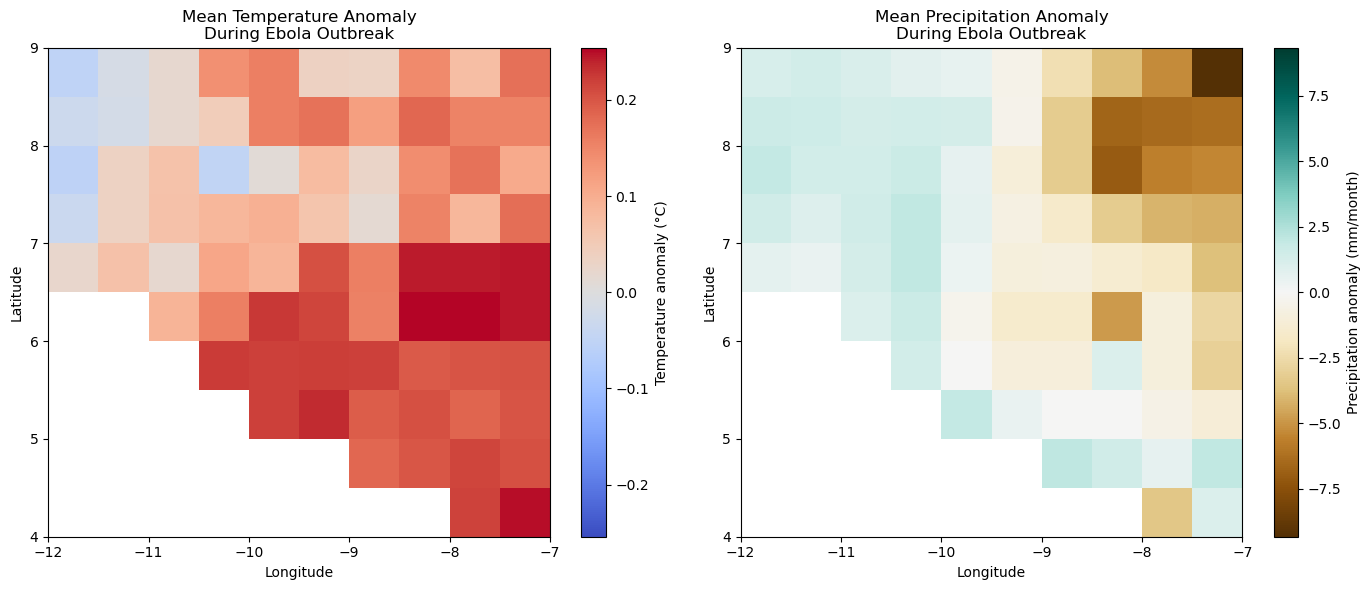

In [158]:
# Check plots: visualization of broad temperature and precipitation conditions across Liberia (2014-2016):
# Extract variables from datasets:
tmp = tmp_ds["tmp"]
pre = pre_ds["pre"]

# Crop to Liberia region:
tmp_lbr = tmp.sel(lon=slice(LON_MIN, LON_MAX),lat=slice(LAT_MIN, LAT_MAX))
pre_lbr = pre.sel(lon=slice(LON_MIN, LON_MAX),lat=slice(LAT_MIN, LAT_MAX))

# Baseline climatology (2001–2013):
tmp_clim = (tmp_lbr.sel(time=slice("2001-01-01", "2013-12-31")).groupby("time.month").mean("time"))
pre_clim = (pre_lbr.sel(time=slice("2001-01-01", "2013-12-31")).groupby("time.month").mean("time"))

# Monthly anomalies:
tmp_anom = tmp_lbr.groupby("time.month") - tmp_clim
pre_anom = pre_lbr.groupby("time.month") - pre_clim

# Outbreak-period mean anomalies:
tmp_outbreak = (tmp_anom.sel(time=slice("2014-03-01", "2016-03-31")).mean("time"))
pre_outbreak = (pre_anom.sel(time=slice("2014-03-01", "2016-03-31")).mean("time"))

# Temperature and precipitation anomaly coarse resolution test plots:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Temperature anomaly coarse resolution test plot:
tmp_outbreak.plot(
    ax=axes[0],
    cmap="coolwarm",
    cbar_kwargs={"label": "Temperature anomaly (°C)"}
)

axes[0].set_title(
    "Mean Temperature Anomaly\nDuring Ebola Outbreak"
)

axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# Precipitation anomaly coarse resolution test plot:
pre_outbreak.plot(
    ax=axes[1],
    cmap="BrBG",
    cbar_kwargs={"label": "Precipitation anomaly (mm/month)"}
)

axes[1].set_title(
    "Mean Precipitation Anomaly\nDuring Ebola Outbreak"
)

axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()

#### 3.3 Compile Ebola county-level case data.
##### Create Ebola case total table by county (cumulative cases for the outbreak period, 2014-2016). County-level Ebola case totals were compiled from public outbreak reports into a clean CSV table for spatial analysis (Source: HDX 'Number of Ebola Cases and Deaths in Affected Countries' Dataset, Liberia Ministry of Health and WHO).

In [159]:
# Create dataframe with Liberian county and Ebola case counts (cumulative for the outbreak by county):
county_cases = pd.DataFrame({
    "county": [
        "Bomi", "Bong", "Gbarpolu", "Grand Bassa", "Grand Cape Mount",
        "Grand Gedeh", "Grand Kru", "Lofa", "Margibi", "Maryland",
        "Montserrado", "Nimba", "River Cess", "River Gee", "Sinoe"
    ],
    "ebola_cases": [
        350, 710, 40, 240, 495,
        50, 25, 940, 1010, 30,
        5410, 325, 40, 35, 45
    ]
})
# Print table of counties and Ebola cases:
county_cases

,county,ebola_cases
0,Bomi,350
1,Bong,710
2,Gbarpolu,40
3,Grand Bassa,240
4,Grand Cape Mount,495
5,Grand Gedeh,50
6,Grand Kru,25
7,Lofa,940
8,Margibi,1010
9,Maryland,30


In [160]:
# Convert table to .csv.
county_cases.to_csv("data/liberia_ebola_county_cases.csv", index=False)

In [161]:
# Read and print .csv data:
county_cases = pd.read_csv("data/liberia_ebola_county_cases.csv")
county_cases.head()

,county,ebola_cases
0,Bomi,350
1,Bong,710
2,Gbarpolu,40
3,Grand Bassa,240
4,Grand Cape Mount,495


##### The original HDX Ebola outbreak records were cleaned and aggregated into a county-level CSV table containing cumulative Ebola case totals for Liberia. Converting the data into CSV format simplified spatial joins, visualization, and integration with climate and land-use datasets within the Python analysis workflow.

#### 3.4 Join Ebola cases to Liberia county boundaries. 
##### County-level Ebola case totals were joined to Liberia administrative boundary shapefiles using standardized county names in order to support spatial mapping and comparison with climate and forest-loss datasets.

In [162]:
# Standardize names for matching:
counties["county_clean"] = counties["NAME_1"].str.lower().str.strip()
county_cases["county_clean"] = county_cases["county"].str.lower().str.strip()

counties_cases = counties.merge(
    county_cases,
    on="county_clean",
    how="left"
)

# Fill counties with no recorded cases as 0:
counties_cases["ebola_cases"] = counties_cases["ebola_cases"].fillna(0)
counties_cases[["NAME_1", "ebola_cases"]].head()

,NAME_1,ebola_cases
0,Bomi,350.0
1,Bong,710.0
2,Gbapolu,0.0
3,Grand Bassa,240.0
4,Grand Cape Mount,495.0


#### 3.5 Calculate Ebola case density by county area.
##### Ebola case density was calculated by normalizing cumulative Ebola cases by county area (km²), allowing outbreak intensity to be compared consistently across counties of different geographic size.

In [163]:
# Reproject to meters so area is accurate:
counties_projected = counties_cases.to_crs("EPSG:3857")
counties_cases["area_km2"] = counties_projected.area / 1_000_000

counties_cases["case_density"] = (
    counties_cases["ebola_cases"] / counties_cases["area_km2"]
)

counties_cases[["NAME_1", "ebola_cases", "area_km2", "case_density"]]

,NAME_1,ebola_cases,area_km2,case_density
0,Bomi,350.0,2151.222188,0.162698
1,Bong,710.0,8564.953997,0.082896
2,Gbapolu,0.0,9462.320441,0.000000
3,Grand Bassa,240.0,7619.256088,0.031499
4,Grand Cape Mount,495.0,5054.824922,0.097926
5,Grand Gedeh,50.0,10432.540802,0.004793
6,Grand Kru,25.0,3740.302465,0.006684
7,Lofa,940.0,10523.969020,0.089320
8,Margibi,1010.0,2864.630138,0.352576
9,Maryland,30.0,2221.984789,0.013501


In [164]:
# Convert Ebola cases column from string to numeric.
counties_cases["ebola_cases"] = pd.to_numeric(counties_cases["ebola_cases"], errors="coerce")
counties_cases["ebola_cases"] = counties_cases["ebola_cases"].fillna(0)

#### This preliminary choropleth map visualizes cumulative Ebola cases by county across Liberia during the 2014–2016 outbreak and serves as an initial spatial reference for comparing outbreak intensity with later climate and forest-loss analyses.

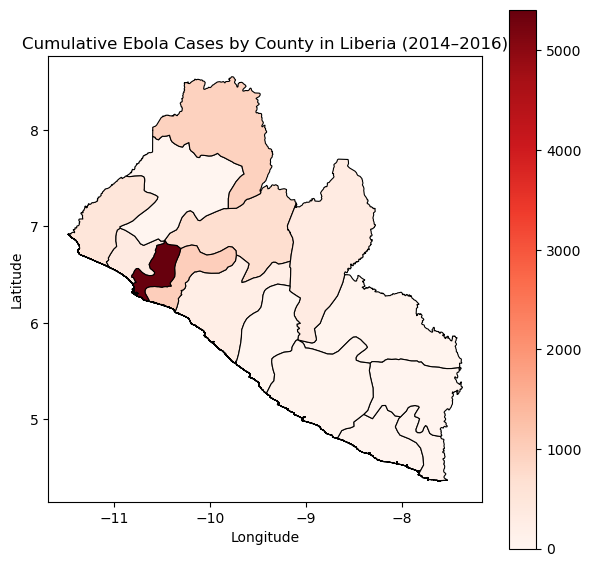

In [177]:
# Check plot: Ebola case density by county area:
fig, ax = plt.subplots(figsize=(7, 7))

counties_cases.plot(
    column="ebola_cases",
    cmap="Reds",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Cumulative Ebola Cases by County in Liberia (2014–2016)")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

#### 3.6 Import Hansen Global Forest Change dataset for Liberia.
##### The Hansen Global Forest Change dataset was imported as a georeferenced raster dataset to identify spatial patterns of forest loss and deforestation across Liberia between 2001 and 2016.

In [166]:
from rioxarray.merge import merge_arrays   # combines multiple raster tiles into a single continuous geospatial dataset for analysis and visualization

# Hansen Global Forest Change tile covering Liberia:
hansen_urls = {
    "loss_10N_010W": "https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_lossyear_10N_010W.tif",
    "loss_10N_020W": "https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_lossyear_10N_020W.tif",
}

loss_tiles = []

for name, url in hansen_urls.items():
    path = os.path.join(DATA_DIR, f"{name}.tif")
    
    if not os.path.exists(path):
        print(f"Downloading {name}...")
        urllib.request.urlretrieve(url, path)
        print("Download complete.")
    else:
        print(f"{name} already exists.")
    
    tile = rioxarray.open_rasterio(path, masked=True).squeeze()
    loss_tiles.append(tile)

# Merge the two tiles into one raster:
loss = merge_arrays(loss_tiles)

print(loss)

loss_10N_010W already exists.
loss_10N_020W already exists.
<xarray.DataArray (y: 40000, x: 80000)> Size: 13GB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)
Coordinates:
  * x            (x) float64 640kB -20.0 -20.0 -20.0 ... -0.000375 -0.000125
  * y            (y) float64 320kB 10.0 10.0 9.999 ... 0.000375 0.000125
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    LAYER_TYPE:     athematic
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      Layer_1


##### This preliminary visualization confirms successful loading, alignment, and spatial coverage of the Hansen forest-loss raster data relative to Liberia county boundaries before further analysis and map production.

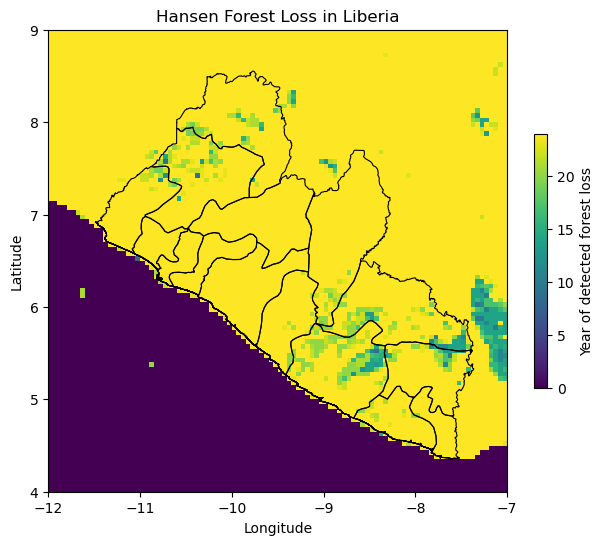

In [178]:
# Check plot: cropped Hansen forest loss raster:
# Crop to Liberia bounding box
loss_liberia = loss.sel(
    x=slice(-12, -7),
    y=slice(9, 4)   # y is often descending
)

# Downsample for faster plotting
loss_small = loss_liberia.coarsen(x=200, y=200, boundary="trim").max()

fig, ax = plt.subplots(figsize=(7, 6))

loss_small.plot(
    ax=ax,
    cmap="viridis",
    cbar_kwargs={
        "label": "Year of detected forest loss",
        "shrink": 0.55,
        "fraction": 0.035
    }
)

counties.boundary.plot(ax=ax, color="black", linewidth=0.8)

ax.set_title("Hansen Forest Loss in Liberia")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

### 3.7 Zonal statistics: forest loss per county.
#### County-level forest-loss statistics were calculated by clipping the Hansen raster data to each Liberia county boundary and summing forest-loss pixels occurring between 2001 and 2016 to quantify relative deforestation intensity by county.

In [168]:
from rasterstats import zonal_stats   # Calculates summary statistics for raster values within polygon boundaries, enabling county-level analysis of forest-loss intensity.

# Create binary raster:
# 1 = forest loss between 2001 and 2016
# 0 = no loss / outside period
loss_2001_2016 = ((loss_liberia >= 1) & (loss_liberia <= 16)).astype("uint8")

# Save temporary raster for zonal statistics:
loss_binary_path = "data/loss_2001_2016_binary.tif"
loss_2001_2016.rio.to_raster(loss_binary_path)

# Calculate number of forest-loss pixels per county:
stats = zonal_stats(
    counties_cases,
    loss_binary_path,
    stats=["sum"],
    nodata=0
)

counties_cases["forest_loss_pixels_2001_2016"] = [
    s["sum"] for s in stats
]

# Normalize to create forest loss index:
counties_cases["forest_loss_index"] = (
    counties_cases["forest_loss_pixels_2001_2016"] /
    counties_cases["forest_loss_pixels_2001_2016"].max()
)

counties_cases[[
    "NAME_1",
    "ebola_cases",
    "case_density",
    "forest_loss_pixels_2001_2016",
    "forest_loss_index"
]]

,NAME_1,ebola_cases,case_density,forest_loss_pixels_2001_2016,forest_loss_index
0,Bomi,350.0,0.162698,624499.0,0.245940
1,Bong,710.0,0.082896,2539237.0,1.000000
2,Gbapolu,0.0,0.000000,796130.0,0.313531
3,Grand Bassa,240.0,0.031499,1763602.0,0.694540
4,Grand Cape Mount,495.0,0.097926,707817.0,0.278752
5,Grand Gedeh,50.0,0.004793,430458.0,0.169523
6,Grand Kru,25.0,0.006684,463811.0,0.182658
7,Lofa,940.0,0.089320,1856127.0,0.730978
8,Margibi,1010.0,0.352576,830339.0,0.327003
9,Maryland,30.0,0.013501,385390.0,0.151774


### 3.8 Extract climate anomalies at county centroids.
#### Because CRU TS is a coarse 0.5° gridded dataset, county-level climate anomalies were assigned using the nearest grid cell to each county centroid. This avoids missing values for small counties whose polygons may not contain a CRU grid-cell center.

In [169]:
# More reliable for coarse CRU grids:
counties_cases = counties_cases.to_crs("EPSG:4326")

# Tell rioxarray/xarray the spatial dimensions:
tmp_outbreak = tmp_outbreak.rio.set_spatial_dims(x_dim="lon", y_dim="lat").rio.write_crs("EPSG:4326")
pre_outbreak = pre_outbreak.rio.set_spatial_dims(x_dim="lon", y_dim="lat").rio.write_crs("EPSG:4326")

# Calculate accurate centroids using projected CRS:
counties_projected = counties_cases.to_crs("EPSG:3857")

centroids_projected = counties_projected.geometry.centroid

centroids = gpd.GeoSeries(
    centroids_projected,
    crs="EPSG:3857"
).to_crs("EPSG:4326")

temp_values = []
precip_values = []

for point in centroids:
    lon = point.x
    lat = point.y

    temp_val = tmp_outbreak.sel(lon=lon, lat=lat, method="nearest").compute().item()
    precip_val = pre_outbreak.sel(lon=lon, lat=lat, method="nearest").compute().item()

    temp_values.append(float(temp_val))
    precip_values.append(float(precip_val))

counties_cases["temp_anom"] = temp_values
counties_cases["precip_anom"] = precip_values

counties_cases[[
    "NAME_1",
    "ebola_cases",
    "case_density",
    "forest_loss_index",
    "temp_anom",
    "precip_anom"
]]

,NAME_1,ebola_cases,case_density,forest_loss_index,temp_anom,precip_anom
0,Bomi,350.0,0.162698,0.245940,0.019384,1.377227
1,Bong,710.0,0.082896,1.000000,0.089232,0.433846
2,Gbapolu,0.0,0.000000,0.313531,0.086770,1.980942
3,Grand Bassa,240.0,0.031499,0.694540,0.225230,-0.353228
4,Grand Cape Mount,495.0,0.097926,0.278752,0.035385,1.010158
5,Grand Gedeh,50.0,0.004793,0.169523,0.196309,1.026157
6,Grand Kru,25.0,0.006684,0.182658,0.199693,1.517236
7,Lofa,940.0,0.089320,0.730978,0.008000,0.640012
8,Margibi,1010.0,0.352576,0.327003,0.110154,2.041857
9,Maryland,30.0,0.013501,0.151774,0.216000,0.616924


## 4.0 Figures
#### The following figures visualize the spatial relationships between climate variability, forest loss, and Ebola outbreak intensity across Liberia during the 2014–2016 epidemic. Together, these maps and exploratory comparisons illustrate how environmental change may have influenced regional patterns of Ebola transmission risk and outbreak severity.

### 4.1 Figure 1: Cumulative Ebola Cases by County
#### Figure 1 displays cumulative Ebola case totals by county and is intended to illustrate overall outbreak burden during the 2014–2016 epidemic. Later analyses use case density values normalized by county area to support more comparable environmental and spatial analyses across counties of different geographic size. A logarithmic normalization (LogNorm) was applied to the Ebola case data because outbreak intensity varied greatly between counties, with a small number of counties containing disproportionately high case totals. Using a logarithmic color scale improves visual differentiation among low- and moderate-case counties while still preserving the relative magnitude of the highest-burden outbreak regions.
#### This figure establishes the spatial pattern of outbreak burden that the later climate and forest-loss figures attempt to explain.

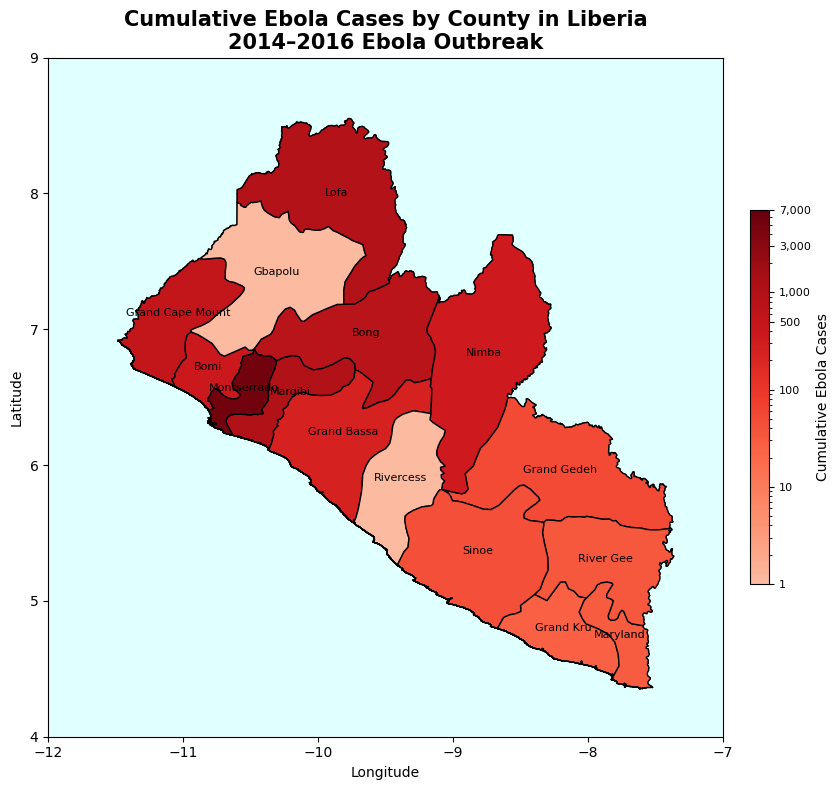

In [170]:
from matplotlib.colors import LogNorm, LinearSegmentedColormap
# Applies logarithmic color scaling to improve visualization of highly uneven data distributions.
# Creates customized color gradients for thematic map visualization.

# Figure size:
fig, ax = plt.subplots(figsize=(10, 8))

# Background/ocean:
ax.set_facecolor("lightcyan")

# Background/land:
counties_cases.plot(
    ax=ax,
    color="oldlace",
    edgecolor="black",
    linewidth=0.8,
    zorder=1
)

# Ebola color scale:
# Avoid log(0) by setting minimum value to 1.
case_norm = LogNorm(vmin=1, vmax=7000)

case_cmap = LinearSegmentedColormap.from_list(
    "custom_reds",
    plt.cm.Reds(np.linspace(0.25, 1, 256))
)

# Plot counties manually using log scale:
counties_cases.plot(
    ax=ax,
    color=[
        case_cmap(case_norm(max(v, 1)))
        for v in counties_cases["ebola_cases"]
    ],
    linewidth=1,
    edgecolor="black",
    zorder=2
)

# Colorbar with readable tick marks:
sm = mpl.cm.ScalarMappable(
    cmap=case_cmap,
    norm=case_norm
)

sm.set_array([]) # Object to represent scalar data for colorbar purposes.

# Plot colorbar:
cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.03,
    pad=0.03,
    shrink=0.55
)

cbar.set_label("Cumulative Ebola Cases", fontsize=10)

cbar.set_ticks([1, 10, 100, 500, 1000, 3000, 7000])
cbar.set_ticklabels(["1", "10", "100", "500", "1,000", "3,000", "7,000"])

cbar.ax.tick_params(labelsize=8)

# County labels and centroids:
counties_projected = counties_cases.to_crs("EPSG:3857")

centroids = gpd.GeoSeries(
    counties_projected.geometry.centroid,
    crs="EPSG:3857"
).to_crs("EPSG:4326")

for idx, row in counties_cases.iterrows():

    centroid = centroids.iloc[idx]

    ax.text(
        centroid.x,
        centroid.y,
        row["NAME_1"],
        fontsize=8,
        ha="center",
        color="black",
        zorder=5
    )
    
# Add lables and legend:
ax.set_title(
    "Cumulative Ebola Cases by County in Liberia\n"
    "2014–2016 Ebola Outbreak",
    fontsize=15,
    weight="bold"
)

ax.set_xlim(-12, -7)
ax.set_ylim(4, 9)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

#### Figure 1 Key Finding: The most cumulative Ebola cases occur in Montserrado County, where the capital and most populous city, Monrovia, is located. 

### 4.2.  Figure 2: Climate Anomalies During the Ebola Outbreak
#### Figure 2 shows mean temperature and precipitation anomalies across Liberia during the 2014-2016 Ebola outbreak period relative to the 2001-2013 baseline climate period. The CRU TS climate grids were interpolated to a finer display grid to improve visualization and readability while preserving the original underlying climate patterns.
#### This figure connects to the hypothesis by showing where climate anomalies occurred during the outbreak period and providing the climate context later compared with county-level Ebola intensity.

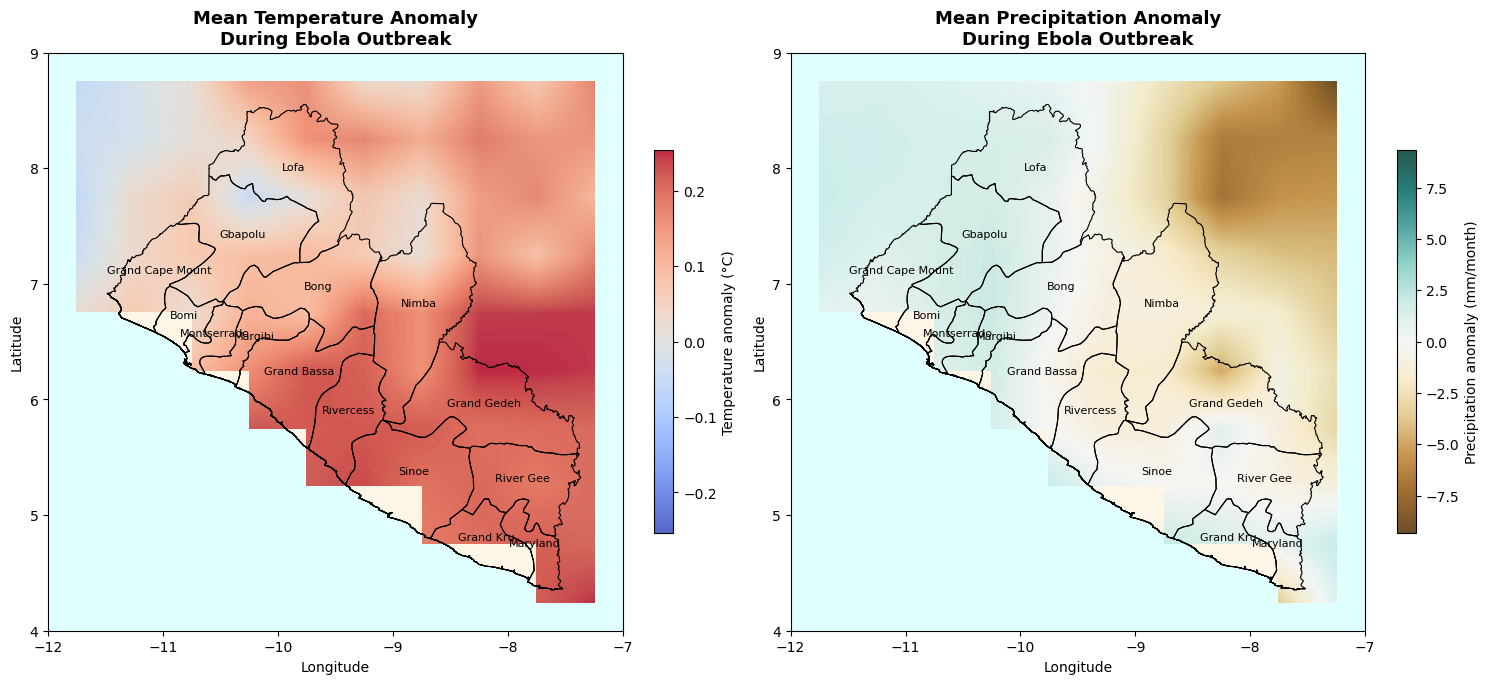

In [171]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Background/ocean:
for ax in axes:
    ax.set_facecolor("lightcyan")

    counties_cases.plot(
        ax=ax,
        color="oldlace",
        edgecolor="black",
        linewidth=0.6,
        zorder=1
    )
    
# Remove sharp pixel edge and smooth CRU anomaly fields for visualization only
tmp_outbreak_smooth = tmp_outbreak.interp(
    lon=np.linspace(float(tmp_outbreak.lon.min()), float(tmp_outbreak.lon.max()), 300),
    lat=np.linspace(float(tmp_outbreak.lat.min()), float(tmp_outbreak.lat.max()), 300)
)

pre_outbreak_smooth = pre_outbreak.interp(
    lon=np.linspace(float(pre_outbreak.lon.min()), float(pre_outbreak.lon.max()), 300),
    lat=np.linspace(float(pre_outbreak.lat.min()), float(pre_outbreak.lat.max()), 300)
)

# Plot temperature anomaly:
tmp_outbreak_smooth.plot(
    ax=axes[0],
    cmap="coolwarm",
    alpha=0.85,
    zorder=2,
    cbar_kwargs={
        "label": "Temperature anomaly (°C)",
        "shrink": 0.6,
        "fraction": 0.04
    }
)

counties_cases.boundary.plot(
    ax=axes[0],
    color="black",
    linewidth=0.8,
    zorder=3
)

axes[0].set_title(
    "Mean Temperature Anomaly\nDuring Ebola Outbreak",
    fontsize=13,
    weight="bold"
)

# Plot precipitation anomaly:

pre_outbreak_smooth.plot(
    ax=axes[1],
    cmap="BrBG",
    alpha=0.85,
    zorder=2,
    cbar_kwargs={
        "label": "Precipitation anomaly (mm/month)",
        "shrink": 0.6,
        "fraction": 0.04
    }
)

counties_cases.boundary.plot(
    ax=axes[1],
    color="black",
    linewidth=0.8,
    zorder=3
)

axes[1].set_title(
    "Mean Precipitation Anomaly\nDuring Ebola Outbreak",
    fontsize=13,
    weight="bold"
)

# Add county labels:
counties_projected = counties_cases.to_crs("EPSG:3857")

centroids = gpd.GeoSeries(
    counties_projected.geometry.centroid,
    crs="EPSG:3857"
).to_crs("EPSG:4326")

for ax in axes:

    for idx, row in counties_cases.iterrows():
        centroid = centroids.iloc[idx]

        ax.text(
            centroid.x,
            centroid.y,
            row["NAME_1"],
            fontsize=8,
            ha="center",
            zorder=5
        )

# Plot axes information:
for ax in axes:
    ax.set_xlim(-12, -7)
    ax.set_ylim(4, 9)

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

#### Figure 2 Key Findings: The climate anomaly maps show relatively modest temperature anomalies across Liberia during the Ebola outbreak period, while precipitation anomalies displayed greater regional variability, with some counties experiencing wetter-than-average conditions and others experiencing drier conditions.

### 4.3.     Figure 3: Time Series of Liberia-Wide Climate Anomalies
#### Figure 3 overlays Liberia-wide temperature and precipitation anomalies from 2010-2016 in order to compare how both climate variables evolved before and during the Ebola outbreak period. Focusing on 2010-2016 minimizes unrelated long-term variability outside the primary study window. Dual y-axes were used because temperature and precipitation anomalies are measured in different units and ranges.
#### This figure evaluates whether Liberia experienced notable temperature or precipitation deviations immediately before and during the epidemic, supporting the climate-variability component of the hypothesis.

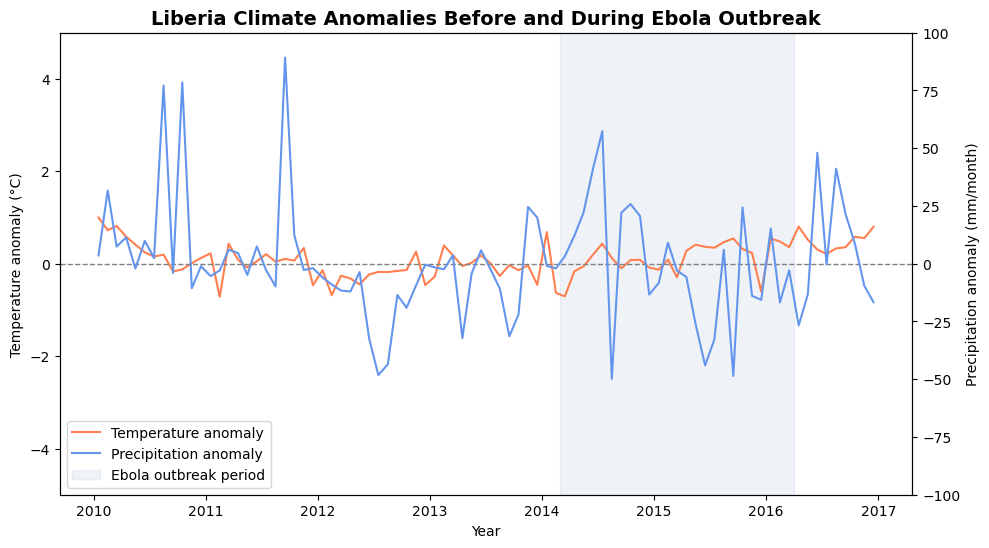

In [172]:
# Define variables and ranges:
tmp_ts = tmp_anom.sel(time=slice("2010-01-01", "2016-12-31")).mean(["lat", "lon"])
pre_ts = pre_anom.sel(time=slice("2010-01-01", "2016-12-31")).mean(["lat", "lon"])

# Plot the anomalies:
fig, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(tmp_ts["time"], tmp_ts, color="coral", linewidth=1.5, label="Temperature anomaly")
ax1.set_ylabel("Temperature anomaly (°C)")
ax1.set_xlabel("Year")
ax1.set_ylim(-5,5)

ax1.axhline(0, color="gray", linestyle="--", linewidth=1)

# Creates a second y-axis on the same plot, allowing temperature and precipitation anomalies to be visualized together.
ax2 = ax1.twinx()   
ax2.plot(pre_ts["time"], pre_ts, color = "cornflowerblue", linewidth=1.5, label="Precipitation anomaly")
ax2.set_ylabel("Precipitation anomaly (mm/month)")
ax2.set_ylim(-100,100)

# Highlights Ebola outbreak period on time series plot via shading.
ax1.axvspan(pd.to_datetime(OUTBREAK_START), pd.to_datetime(OUTBREAK_END), alpha=0.2, color="lightsteelblue", label="Ebola outbreak period")   
ax1.set_title("Liberia Climate Anomalies Before and During Ebola Outbreak", fontsize=14, weight="bold")

# Plot legend:
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines = lines1 + lines2
labels = labels1 + labels2

order = [0, 2, 1]

ax1.legend(
    [lines[i] for i in order],
    [labels[i] for i in order],
    loc="lower left"
)

plt.show()

#### Figure 3 Key Findings: The time-series analysis suggests that Liberia did not experience extreme nationwide temperature anomalies during the outbreak period, although precipitation variability fluctuated more substantially before and during the epidemic. 

### 4.4.     Figure 4: Precipitation Anomaly vs. Ebola Case Density
#### Figure 4 compares county-level precipitation and anomalies during the Ebola outbreak period with Ebola case density in order to explore whether unusually wet or dry climate conditions were associated with greater outbreak intensity across Liberia.
#### This figure tests one part of the hypothesis by examining whether counties with stronger precipitation anomalies also had higher Ebola case density.

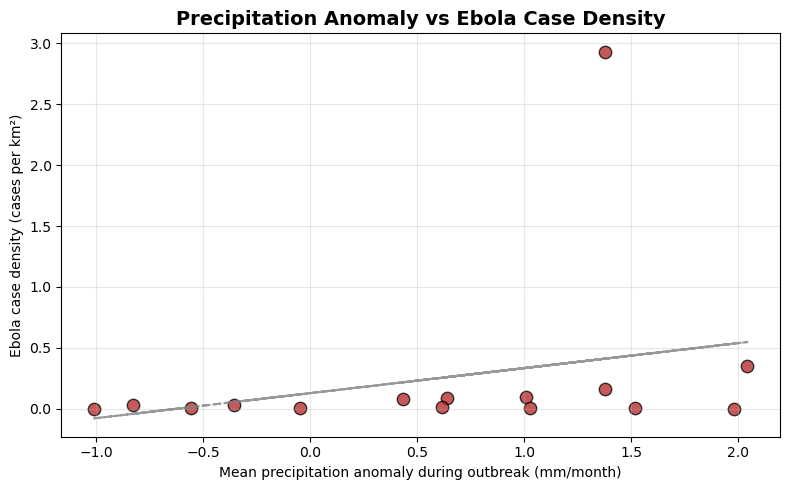

In [173]:
fig, ax = plt.subplots(figsize=(8, 5))

# Create scatterplot:
ax.scatter(
    counties_cases["precip_anom"],
    counties_cases["case_density"],
    s=80,
    color="firebrick",
    edgecolor="black",
    alpha=0.75
)

ax.set_title(
    "Precipitation Anomaly vs Ebola Case Density",
    fontsize=14,
    weight="bold"
)

ax.set_xlabel("Mean precipitation anomaly during outbreak (mm/month)")
ax.set_ylabel("Ebola case density (cases per km²)")

ax.grid(True, alpha=0.3)

# Add regression line:
x = counties_cases["precip_anom"].to_numpy()
y = counties_cases["case_density"].to_numpy()
mask = np.isfinite(x) & np.isfinite(y)

m, b = np.polyfit(x[mask], y[mask], 1)
ax.plot(x[mask], m * x[mask] + b, linewidth=1.5, linestyle="--", alpha=0.8, color="gray")

plt.tight_layout()
plt.show()

#### Figure 4 Key Findings: The scatterplot suggests a weak positive relationship between precipitation anomaly and Ebola case density, though the pattern appears strongly influenced by a small number of high-burden counties.
#### The scatterplot contains a major high-density outlier associated with Montserrado County (value near 3.0 cases per square km), where Ebola transmission was likely influenced strongly by urban population density, healthcare infrastructure, and human mobility in addition to environmental conditions. This suggests that precipitation anomalies alone do not explain variation in outbreak intensity across Liberia.

### 4.5. Figure 5: Forest Loss vs. Ebola Case Density (Shaded by Temperature Anomaly)
#### Figure 5 compares county-level forest-loss intensity with Ebola case density to explore whether counties experiencing greater deforestation also exhibited higher outbreak intensity during the 2014-2016 Ebola outbreak in Liberia.
#### This figure directly examines the relationship between forest loss and Ebola case density while using temperature anomaly as an additional climate-stress indicator.

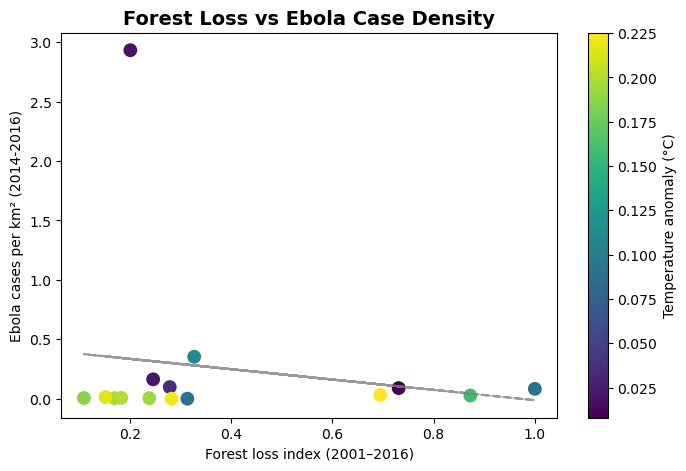

In [174]:
fig, ax = plt.subplots(figsize=(8, 5))

# Create scatterplot:
sc = ax.scatter(
    counties_cases["forest_loss_index"],
    counties_cases["case_density"],
    c=counties_cases["temp_anom"],
    s=80
)

# Add colorbar:
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Temperature anomaly (°C)")

# Add regression line:
x = counties_cases["forest_loss_index"].to_numpy()
y = counties_cases["case_density"].to_numpy()
mask = np.isfinite(x) & np.isfinite(y)

m, b = np.polyfit(x[mask], y[mask], 1)
ax.plot(x[mask], m * x[mask] + b, linewidth=1.5, linestyle="--", alpha=0.8, color="gray")

ax.set_title("Forest Loss vs Ebola Case Density",fontsize=14, weight="bold")
ax.set_xlabel("Forest loss index (2001–2016)")
ax.set_ylabel("Ebola cases per km² (2014-2016)")

plt.show()

#### Figure 5 Key Findings: Contrary to the initial hypothesis, the highest Ebola case densities do not appear to occur in counties with the greatest forest-loss index; instead, some counties with moderate or lower forest-loss values show higher outbreak intensity.
#### A major outbreak-density outlier is visible for Montserrado County, indicating that the highest Ebola burden occurred in a county with relatively moderate forest-loss intensity. This suggests that urban transmission dynamics and population concentration may have played a larger role in overall outbreak intensity than forest loss alone.

### 4.6. Figure 6: Group Bar Chart for Combined Risk Categories
#### Figure 6 compares Ebola case density across combined forest-loss and climate-anomaly categories in order to evaluate whether counties experiencing both elevated deforestation and stronger climate anomalies exhibited greater outbreak intensity than counties exposed to only one or neither environmental stressor.
#### This figure provides the clearest grouped test of the hypothesis by comparing Ebola case density across counties with different combinations of forest-loss and climate-anomaly exposure.

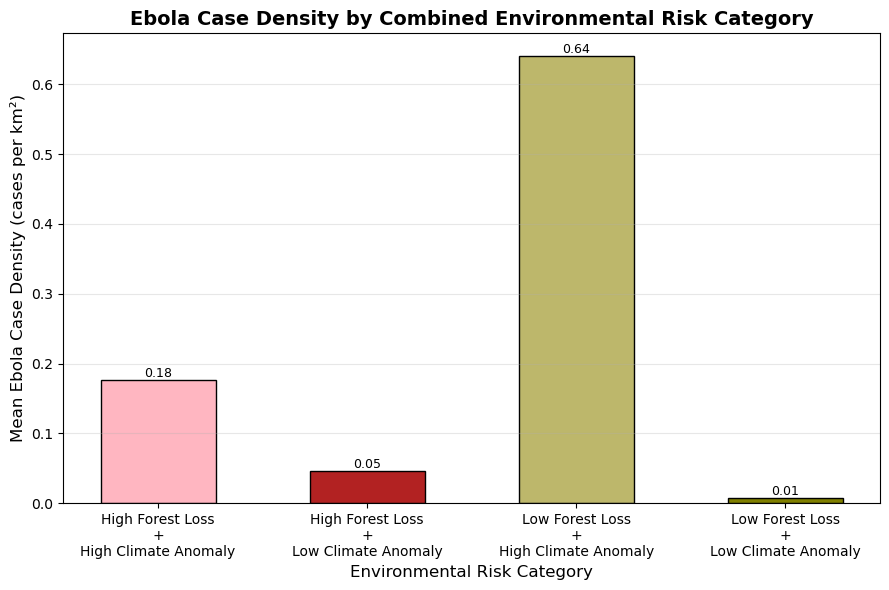

In [175]:
# Create high/low forest-loss categories:
# Counties above the median are classified as "High."
counties_cases["forest_category"] = np.where(
    counties_cases["forest_loss_index"] >
    counties_cases["forest_loss_index"].median(),
    "High Forest Loss",
    "Low Forest Loss")

# Create high/low precipitation anomaly categories:
counties_cases["climate_category"] = np.where(
    counties_cases["precip_anom"] >
    counties_cases["precip_anom"].median(),
    "High Climate Anomaly",
    "Low Climate Anomaly"
)

# Combine categories into one risk grouping:
counties_cases["risk_group"] = (counties_cases["forest_category"] + "\n+\n" + counties_cases["climate_category"])

# Calculate mean Ebola case density for each group:
grouped = (
    counties_cases
    .groupby("risk_group")["case_density"]
    .mean()
    .reset_index()
)

# Plot grouped bar chart:
fig, ax = plt.subplots(figsize=(9, 6))

# Bar colors:
colors = [
    "lightpink",
    "firebrick",
    "darkkhaki",
    "olive"
]

bars = ax.bar(
    grouped["risk_group"],
    grouped["case_density"],
    width=0.55,
    color=colors,
    edgecolor="black",
    linewidth=1
)

# Add bar labels
for bar in bars:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Add title:
ax.set_title(
    "Ebola Case Density by Combined Environmental Risk Category",
    fontsize=14,
    weight="bold"
)

ax.set_ylabel("Mean Ebola Case Density (cases per km²)", fontsize=12)
ax.set_xlabel("Environmental Risk Category", fontsize=12)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

#### Figure 6 Key Findings: The grouped comparison suggests that combined environmental risk categories do not clearly produce a simple gradient of increasing Ebola case density, indicating that forest loss and climate anomalies alone may not explain outbreak intensity.

### 4.7. Forest Loss and Ebola Outbreak Intensity in Liberia: Hansen Forest Loss Pixels and County-Level Ebola Cases, 2014–2016
#### Figure 7 overlays Hansen Global Forest Change forest-loss pixels with county-level cumulative Ebola case counts. The raster background shows spatially explicit forest loss, while proportional red circles represent Ebola outbreak intensity by county. This visualization directly supports the project question by showing whether higher Ebola burden appears near areas of greater forest loss.
#### This figure visually integrates the project’s main variables, showing whether areas of forest loss spatially coincide with counties experiencing larger Ebola outbreak burdens.

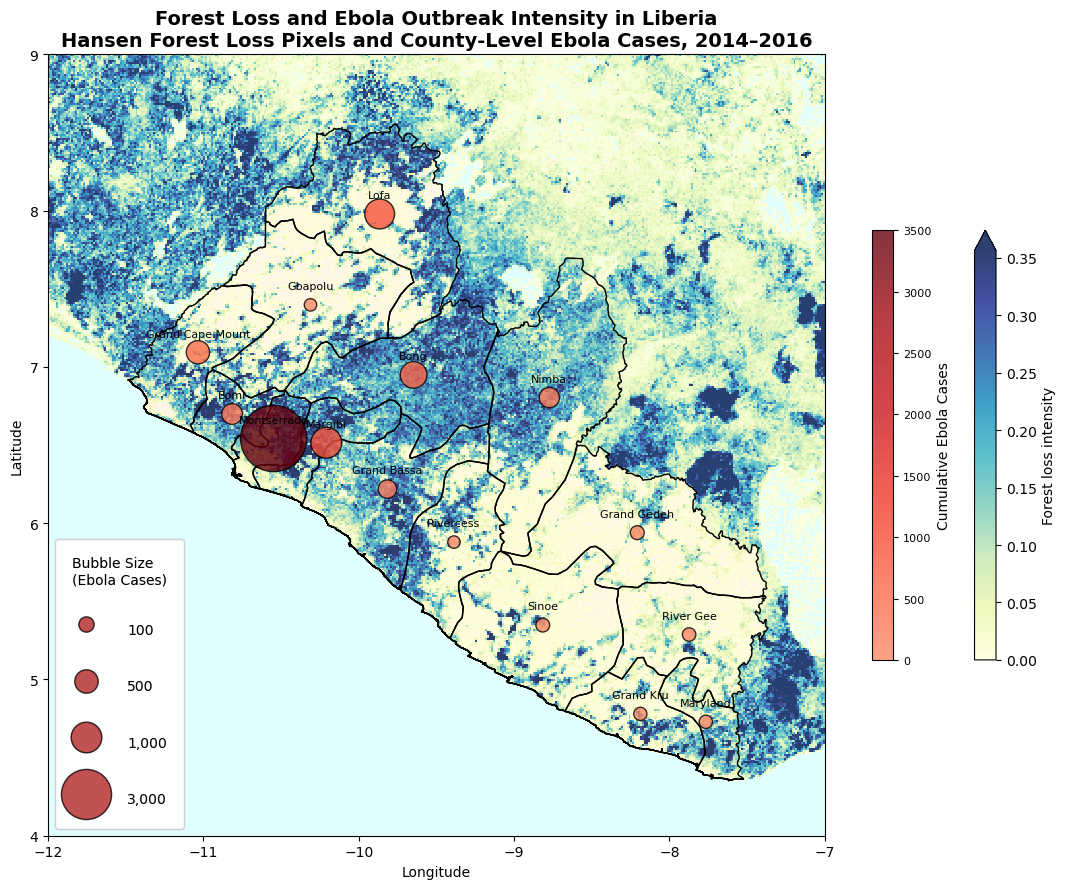

In [176]:
from matplotlib.colors import LinearSegmentedColormap

fig, ax = plt.subplots(figsize=(15, 9))

# Create light cyan background for Atlantic Ocean:
ax.set_facecolor("lightcyan")

# Create county landform background:
counties_cases.plot(
    ax=ax,
    color="oldlace",
    edgecolor="black",
    linewidth=1,
    zorder=1
)

# 1 = forest loss during 2001–2016, 0 = no loss
forest_loss_binary = ((loss_liberia >= 1) & (loss_liberia <= 16)).astype(float)

# Downsample: mean = proportion of pixels lost in each coarse cell
forest_loss_intensity = forest_loss_binary.coarsen(
    x=50,
    y=50,
    boundary="trim"
).mean()

# Mask only cells with zero forest loss
forest_loss_intensity = forest_loss_intensity.where(forest_loss_intensity > 0)

forest_loss_intensity.plot(
    ax=ax,
    cmap="YlGnBu",
    alpha=0.85,
    vmin=0,
    vmax=float(forest_loss_intensity.quantile(0.95)),
    add_colorbar=True,
    cbar_kwargs={
        "label": "Forest loss intensity",
        "shrink": 0.55
    },
    zorder=2
)
cbar.ax.tick_params(labelsize=8)

# County boundaries
counties_cases.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1,
    zorder=3
)

# Accurate centroids
counties_projected = counties_cases.to_crs("EPSG:3857")
centroids = gpd.GeoSeries(
    counties_projected.geometry.centroid,
    crs="EPSG:3857"
).to_crs("EPSG:4326")

# Ebola outbreak circles with color scaling

# Normalize Ebola cases for color mapping
case_norm = plt.Normalize(0, 3500)

case_cmap = LinearSegmentedColormap.from_list(
    "custom_reds",
    plt.cm.Reds(np.linspace(0.4, 1, 256))
)

# Circle sizes
sizes = (
    80 +
    (
        counties_cases["ebola_cases"] /
    counties_cases["ebola_cases"].max()
) * 2200
)

# Plot circles
scatter = ax.scatter(
    centroids.x,
    centroids.y,
    s=sizes,
    c=counties_cases["ebola_cases"],
    cmap=case_cmap,
    norm=case_norm,
    alpha=0.8,
    edgecolor="black",
    linewidth=1,
    zorder=5
)

# Ebola colorbar
cbar_cases = fig.colorbar(
    scatter,
    ax=ax,
    fraction=0.025,   # thinner
    pad=0.04,         # closer to map
    shrink=0.55       # shorter
)

cbar_cases.set_label(
    "Cumulative Ebola Cases",
    fontsize=10
)
cbar_cases.ax.tick_params(labelsize=8)

# Bubble-size legend:
legend_sizes = [100, 500, 1000, 3000]

legend_markers = [
    plt.scatter(
        [],
        [],
        s=80+ ((s / counties_cases["ebola_cases"].max()) * 2200),
        color="firebrick",
        alpha=0.75,
        edgecolor="black"
    )
    for s in legend_sizes
]

legend = ax.legend(
    legend_markers,
    [f"{s:,}" for s in legend_sizes],
    title="Bubble Size\n(Ebola Cases)",
    loc="lower left",
    frameon=True,
    labelspacing=2.2,
    borderpad=1.2,
    handleheight=2.5,
    handletextpad=2.0   # <-- increases space between dot and text
)

ax.add_artist(legend)

# County labels
for idx, row in counties_cases.iterrows():
    centroid = centroids.iloc[idx]
    ax.text(
        centroid.x,
        centroid.y + 0.10,
        row["NAME_1"],
        fontsize=8,
        ha="center",
        color="black",
        zorder=6
    )

ax.set_title(
    "Forest Loss and Ebola Outbreak Intensity in Liberia\n"
    "Hansen Forest Loss Pixels and County-Level Ebola Cases, 2014–2016",
    fontsize=14,
    weight="bold"
)

ax.set_xlim(-12, -7)
ax.set_ylim(4, 9)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

#### Figure 7 Key Findings: The integrated map shows some spatial overlap between forest-loss areas and Ebola burden, but the largest Ebola outbreak burden is concentrated in Montserrado, suggesting that population density, urban transmission, health infrastructure, and human mobility likely played major roles beyond environmental exposure.

### Conclusion and Methodological Reflection (Limitations)

#### The original project concept proposed analyzing fine-scale Ebola outbreak clusters near forest–savannah transition zones, but the final analysis shifted to county-level outbreak intensity because reliable epidemiological data were most consistently available at the county scale. In addition, the CRU TS climate dataset used in this project has a relatively coarse 0.5° spatial resolution, making county-level aggregation a more appropriate analytical scale for integrating climate, land-use, and outbreak datasets.

#### As a result, the project evolved from a fine-scale cluster analysis toward a county-level ecological spatial analysis of Ebola outbreak intensity. This methodological adjustment improved consistency between datasets while still allowing investigation of the broader research question: whether regions experiencing greater forest loss and climate anomalies also experienced higher Ebola outbreak burden. The final analysis therefore emphasizes spatial relationships between environmental change and outbreak intensity rather than individual outbreak clusters or transmission pathways.

#### Because county-level Ebola surveillance data may be incomplete or inconsistently reported, this project should be interpreted as an exploratory spatial analysis rather than a causal model. The analysis tests whether Ebola burden is spatially associated with climate anomalies and forest-loss indicators, but it cannot prove that climate variability or deforestation caused Ebola transmission.

#### Overall, the figures provide limited support for a simple version of the hypothesis. Forest loss and climate anomalies appear relevant as environmental context, but the strongest Ebola burden does not consistently align with the highest deforestation areas, suggesting that social, demographic, and infrastructural factors likely shaped outbreak intensity alongside environmental conditions.

#### The presence of a strong urban outlier highlights an important distinction between factors influencing initial zoonotic spillover risk (emergence) and factors influencing large-scale human-to-human outbreak amplification (transmission). While environmental change may contribute to spillover conditions, urban density and mobility likely shaped the largest outbreak concentrations observed during the epidemic.

### Next Steps
#### Future research could build on this project by analyzing individual high-burden counties at a finer spatial scale using village-level Ebola case data, forest-edge metrics, population density, and transportation networks. This would allow for a true cluster analysis testing whether Ebola transmission was concentrated near forest fragmentation zones or forest–settlement boundaries, rather than relying on county-level averages.

#### Incorporating case-level exposure data describing how Ebola infections were contracted, especially whether early cases involved wildlife exposure, bushmeat handling, hunting, forest work, caregiving, burial practices, or later human-to-human transmission could also be researched. Adding this layer would help distinguish potential zoonotic spillover events from secondary transmission and would allow researchers to test whether animal-contact cases were more likely to occur near areas of forest loss, fragmentation, or forest–settlement boundaries. This would strengthen the analysis by linking environmental change not only to outbreak intensity, but also to specific exposure pathways.

### AI Disclosure Statement:
#### AI tools (ChatGPT, Gemini) were used to support project organization, code troubleshooting, figure design refinement (new plotting tools not used in class), and refining grammar for explanatory notebook text. All research decisions, dataset selection, data interpretation, code execution, and final revisions were completed by the author. 

### References (Datasets)
##### 1. CRU TS v4.08 Dataset: https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.08/
##### 2. Hansen Global Forest Change Dataset: https://earthenginepartners.appspot.com/science-2013-global-forest
##### 3. Humanitarian Data Exchange Ebola Cases Dataset: https://data.humdata.org/dataset/ebola-cases-2014
##### 4. GADM Liberia Administrative Boundaries: https://gadm.org/data.html

### References (Scholarly Articles)
##### Koren, O. (2025). Fire-Driven Land Cover Change and Zoonotic Disease Risk in African Landscapes. EcoHealth 22, 604–612. https://doi.org/10.1007/s10393-025-01743-9
##### Rulli, M. C., D’Odorico, P., Galli, N., John, R. S., Muylaert, R. L., Santini, M., & Hayman, D. T. S. (2025). Land use change and infectious disease emergence. Reviews of Geophysics, 63, e2022RG000785. https://doi.org/10.1029/2022RG000785
##### Rulli, M. C., Santini, M., Hayman, D. T., & D’Odorico, P. (2017). The nexus between forest fragmentation in Africa and Ebola virus disease outbreaks. Scientific Reports, 7(1), 41613.
##### WHO Ebola Response Team. (2016). After Ebola in West Africa—unpredictable risks, preventable epidemics. New England Journal of Medicine, 375(6), 587-596.